(512, 217, 204)


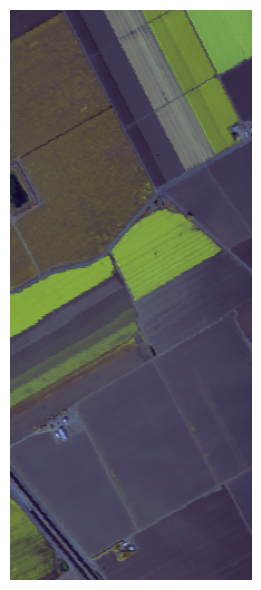

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from utils.dataset import load_mat_hsi

# Load data
image, gt, labels = load_mat_hsi("sa", "./datasets")

print(image.shape)  # (H, W, Bands)

# Take first 3 spectral bands
# rgb = image[:, :, 3:6]
rgb = image[:, :, [70, 40, 20]]
# Normalize for visualization (important!)
rgb_min = rgb.min()
rgb_max = rgb.max()
rgb = (rgb - rgb_min) / (rgb_max - rgb_min)

# Plot
plt.figure(figsize=(3, 6))
plt.imshow(rgb)
plt.axis('off')
plt.tight_layout()
plt.show()


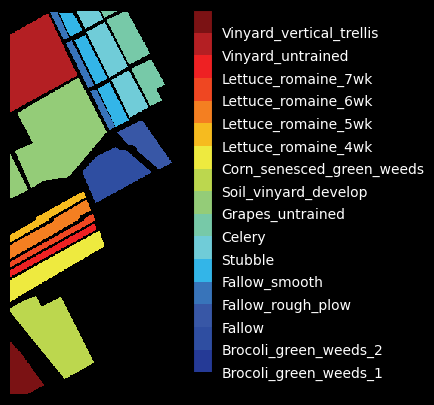

array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       ...,
       [16, 16, 16, ...,  0,  0,  0],
       [16, 16, 16, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]])

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from utils.dataset import load_mat_hsi


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm


palette = np.array([[37, 58, 150],
                    [47, 78, 161],
                    [56, 87, 166],
                    [56, 116, 186],
                    [51, 181, 232],
                    [112, 204, 216],
                    [119, 201, 168],
                    [148, 204, 120],
                    [188, 215, 78],
                    [238, 234, 63],
                    [246, 187, 31],
                    [244, 127, 33],
                    [239, 71, 34],
                    [238, 33, 35],
                    [180, 31, 35],
                    [123, 18, 20]])


# Load dataset
X, y, label_names = load_mat_hsi('sa', './datasets')

class_num = 16
height, width = y.shape

# Flatten labels
y_flat = y.reshape(-1)



def plot_gt_black_background(y, palette, label_names=None, ignore_label=0):
    """
    y: (H, W) ground truth label map
    ignore_label: background / unlabeled class (often 0 or -1)
    """
    y = np.array(y)

    class_num = len(palette)

    # --- mask background ---
    masked_y = y.copy()

    # turn background into -1 so it renders as black
    masked_y[masked_y == ignore_label] = -1

    # add black color at index 0 of colormap
    cmap_colors = np.vstack([[0, 0, 0], palette[:class_num] / 255.0])
    cmap = ListedColormap(cmap_colors)

    # shift labels: -1 -> 0 (black), others -> +1 offset
    display_y = masked_y + 1

    bounds = np.arange(class_num + 2)
    norm = BoundaryNorm(bounds, cmap.N)

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor('black')
    ax.set_facecolor('black')

    im = ax.imshow(display_y, cmap=cmap, norm=norm, interpolation='nearest')

    ax.axis("off")

    # colorbar (skip background)
    cbar = plt.colorbar(im, ticks=np.arange(1, class_num + 1))

    if label_names is not None:
        cbar.ax.set_yticklabels(label_names[:class_num])
    else:
        cbar.ax.set_yticklabels([str(i) for i in range(class_num)])

    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

    plt.show()

    return display_y


plot_gt_black_background(y, palette, label_names)


(145, 145, 200)


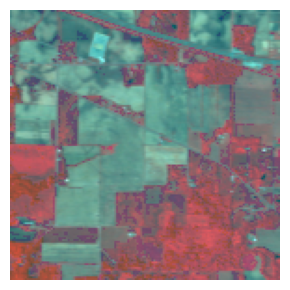

In [54]:
import numpy as np
import matplotlib.pyplot as plt

from utils.dataset import load_mat_hsi

# Load data
image, gt, labels = load_mat_hsi("ip", "./datasets")

print(image.shape)  # (H, W, Bands)

# Take first 3 spectral bands
rgb = image[:, :, [43, 21, 11]]
# Normalize for visualization (important!)
rgb_min = rgb.min()
rgb_max = rgb.max()
rgb = (rgb - rgb_min) / (rgb_max - rgb_min)

# Plot
plt.figure(figsize=(3, 3))
plt.imshow(rgb)
plt.axis('off')
plt.tight_layout()
plt.show()


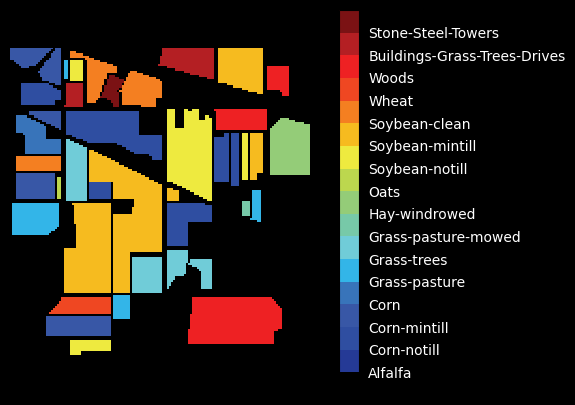

array([[3, 3, 3, ..., 0, 0, 0],
       [3, 3, 3, ..., 0, 0, 0],
       [3, 3, 3, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

import numpy as np
import matplotlib.pyplot as plt
from utils.dataset import load_mat_hsi


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm


palette = np.array([[37, 58, 150],
                    [47, 78, 161],
                    [56, 87, 166],
                    [56, 116, 186],
                    [51, 181, 232],
                    [112, 204, 216],
                    [119, 201, 168],
                    [148, 204, 120],
                    [188, 215, 78],
                    [238, 234, 63],
                    [246, 187, 31],
                    [244, 127, 33],
                    [239, 71, 34],
                    [238, 33, 35],
                    [180, 31, 35],
                    [123, 18, 20]])


# Load dataset
X, y, label_names = load_mat_hsi('ip', './datasets')

class_num = 16
height, width = y.shape

# Flatten labels
y_flat = y.reshape(-1)

def plot_gt_black_background(y, palette, label_names=None, ignore_label=0):
    """
    y: (H, W) ground truth label map
    ignore_label: background / unlabeled class (often 0 or -1)
    """
    y = np.array(y)

    class_num = len(palette)

    # --- mask background ---
    masked_y = y.copy()

    # turn background into -1 so it renders as black
    masked_y[masked_y == ignore_label] = -1

    # add black color at index 0 of colormap
    cmap_colors = np.vstack([[0, 0, 0], palette[:class_num] / 255.0])
    cmap = ListedColormap(cmap_colors)

    # shift labels: -1 -> 0 (black), others -> +1 offset
    display_y = masked_y + 1

    bounds = np.arange(class_num + 2)
    norm = BoundaryNorm(bounds, cmap.N)

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor('black')
    ax.set_facecolor('black')

    im = ax.imshow(display_y, cmap=cmap, norm=norm, interpolation='nearest')

    ax.axis("off")

    # colorbar (skip background)
    cbar = plt.colorbar(im, ticks=np.arange(1, class_num + 1))

    if label_names is not None:
        cbar.ax.set_yticklabels(label_names[:class_num])
    else:
        cbar.ax.set_yticklabels([str(i) for i in range(class_num)])

    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

    plt.show()

    return display_y


plot_gt_black_background(y, palette, label_names)



(550, 400, 270)


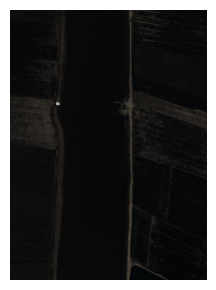

In [67]:
import numpy as np
import matplotlib.pyplot as plt

from utils.dataset import load_mat_hsi

# Load data
image, gt, labels = load_mat_hsi("whulk", "./datasets")

print(image.shape)  # (H, W, Bands)

# Take first 3 spectral bands
rgb = image[:, :, [50, 30, 20]]
# Normalize for visualization (important!)
rgb_min = rgb.min()
rgb_max = rgb.max()
rgb = (rgb - rgb_min) / (rgb_max - rgb_min)

# Plot
plt.figure(figsize=(3, 3))
plt.imshow(rgb)
plt.axis('off')
plt.tight_layout()
plt.show()


[[-1 -1 -1 ... -1 -1 -1]
 [ 0  0  0 ...  3  3  3]
 [ 0  0  0 ...  3  3  3]
 ...
 [ 0  0  0 ... -1 -1 -1]
 [ 0  0  0 ... -1 -1 -1]
 [ 0  0  0 ... -1 -1 -1]]


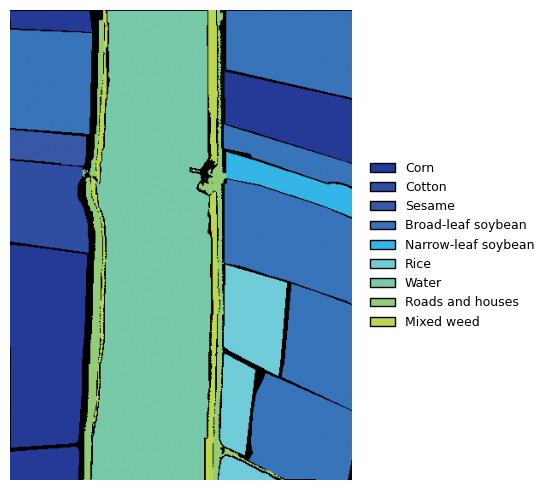

array([[[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.14509804, 0.22745098, 0.58823529],
        [0.14509804, 0.22745098, 0.58823529],
        [0.14509804, 0.22745098, 0.58823529],
        ...,
        [0.21960784, 0.45490196, 0.72941176],
        [0.21960784, 0.45490196, 0.72941176],
        [0.21960784, 0.45490196, 0.72941176]],

       [[0.14509804, 0.22745098, 0.58823529],
        [0.14509804, 0.22745098, 0.58823529],
        [0.14509804, 0.22745098, 0.58823529],
        ...,
        [0.21960784, 0.45490196, 0.72941176],
        [0.21960784, 0.45490196, 0.72941176],
        [0.21960784, 0.45490196, 0.72941176]],

       ...,

       [[0.14509804, 0.22745098, 0.58823529],
        [0.14509804, 0.22745098, 0.58823529],
        [0.14509804, 0

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

import numpy as np
import matplotlib.pyplot as plt
from utils.dataset import load_mat_hsi


palette = np.array([[37, 58, 150],
                    [47, 78, 161],
                    [56, 87, 166],
                    [56, 116, 186],
                    [51, 181, 232],
                    [112, 204, 216],
                    [119, 201, 168],
                    [148, 204, 120],
                    [188, 215, 78],
                    # [238, 234, 63],
                    # [246, 187, 31],
                    # [244, 127, 33],
                    # [239, 71, 34],
                    # [238, 33, 35],
                    # [180, 31, 35],
                    # [123, 18, 20]
                    ])


# Load dataset
X, y, label_names = load_mat_hsi('whulk', './datasets')
print (y)
class_num = 9
height, width = y.shape

# Flatten labels
y_flat = y.reshape(-1)


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_gt_black_background(y, palette, label_names=None):

    y = np.array(y)

    class_num = len(palette)

    rgb = np.zeros((y.shape[0], y.shape[1], 3), dtype=float)

    cmap = palette[:class_num] / 255.0

    for i in range(class_num):
        rgb[y == i] = cmap[i]

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.imshow(rgb)
    ax.axis("off")

    # ===== ADD LABELS BESIDE IMAGE =====
    if label_names is not None:

        handles = [
            Patch(facecolor=cmap[i], edgecolor='black', label=label_names[i])
            for i in range(class_num)
        ]

        ax.legend(
            handles=handles,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            fontsize=9,
            frameon=False
        )

    plt.tight_layout()
    plt.show()

    return rgb
    
plot_gt_black_background(y, palette, label_names=label_names)



In [40]:
import torch.nn as nn
import torch
import math


class GroupedDilationBlock(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size,
                 stride,
                 dilations):
        super(GroupedDilationBlock, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.dilations = dilations
        self.groups = len(self.dilations)

        assert self.in_channels % self.groups == 0
        assert self.out_channels % self.groups == 0
        self.group_size = self.in_channels // self.groups
        self.out_group_size = self.out_channels // self.groups

        convs = []
        for d in self.dilations:
            # pad = ((kernel_size - 1) * d) // 2 # for onnx export purpose
            convs.append(nn.Conv2d(self.group_size,
                                   self.out_group_size,
                                   kernel_size,
                                   padding='same',
                                   dilation=d,
                                   # When `group_size == out_group_size` → Depthwise convolution (within each dilation group).
                                   # Each input channel maps to exactly one output channel, no cross-channel mixing.
                                   # This is the depthwise part of a depthwise separable convolution.
                                   groups=self.group_size if self.group_size==self.out_group_size else 1))
        self.convs = nn.ModuleList(convs)

        self.skip_conn = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride) if in_channels != out_channels else nn.Identity()
        self.bn = nn.BatchNorm2d(in_channels)
        self.activation = nn.ReLU6()

    def forward(self, x):
        skip = self.skip_conn(x)

        x_reshaped = x.view(x.shape[0],
                            self.groups,
                            self.group_size,
                            x.shape[2],
                            x.shape[3])
        out_shape = list(x.shape)
        out_shape[1] = self.out_channels
        out = torch.empty(out_shape, device=x.device)
        for i, conv in enumerate(self.convs):
            out[:, i * self.group_size:(i + 1) * self.group_size] = conv(x_reshaped[:, i])

        out = self.activation(self.bn(out))
        out = out + skip

        return out


class ScaleAttention(nn.Module):
    """
    SKNet-style scale attention (Step 1 of 2) with Conv1d replacing
    the FC bottleneck for efficiency.
    Local cross-channel interactions guide per-scale softmax weights,
    avoiding the expensive linear projection.
    """
    def __init__(self, channels, num_scales=3, kernel_size=3):
        super().__init__()
        self.num_scales = num_scales

        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        # One Conv1d per scale with fixed small kernel
        self.convs = nn.ModuleList([
            nn.Conv1d(1, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False)
            for _ in range(num_scales)
        ])
        self.softmax = nn.Softmax(dim=1)

    def forward(self, scale_features: list):
        """
        scale_features: list of (B, C, H, W) tensors, one per scale.
        Returns: (B, C, H, W) scale-attended feature map.
        """
        # GAP each scale independently
        gaps = [self.avg_pool(u).squeeze(-1).squeeze(-1)
                for u in scale_features]                      # list of (B, C)

        # Per-scale Conv1d for local cross-channel context
        scores = []
        for i, gap in enumerate(gaps):
            y = gap.unsqueeze(1)                              # (B, 1, C)
            y = self.convs[i](y)                             # (B, 1, C)
            scores.append(y.squeeze(1))                      # (B, C)

        # Softmax across scales
        scores = torch.stack(scores, dim=1)                  # (B, num_scales, C)
        attn = self.softmax(scores)                          # (B, num_scales, C)
        attn = attn.unsqueeze(-1).unsqueeze(-1)              # (B, num_scales, C, 1, 1)

        # Weighted sum across scales
        U_stack = torch.stack(scale_features, dim=1)         # (B, num_scales, C, H, W)
        out = (U_stack * attn).sum(dim=1)                    # (B, C, H, W)
        return out


class EfficientChannelAttention(nn.Module):
    """
    ECA-Net style channel attention (Step 2 of 2).
    Replaces SE's FC bottleneck with a lightweight 1D conv over the
    channel dimension, capturing local cross-channel interactions
    without dimensionality reduction — fewer parameters, no info loss.

    Reference:
        Wang et al., ECA-Net: Efficient Channel Attention for Deep
        Convolutional Neural Networks, CVPR 2020.
    """
    def __init__(self, channels, gamma=2, b=1):
        super(EfficientChannelAttention, self).__init__()

        self.channels = channels
        self.gamma = gamma
        self.b = b

        # Adaptive kernel size: larger C → larger k, always odd
        t = int(abs((math.log(channels, 2) + b) / gamma))
        k = t if t % 2 else t + 1

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(
            in_channels=1,
            out_channels=1,
            kernel_size=k,
            padding=k // 2,
            bias=False
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        """
        x: (B, C, H, W) — output of ScaleAttention.
        Returns: (B, C, H, W) channel-attended feature map.
        """
        y = self.avg_pool(x)                           # (B, C, 1, 1)
        y = y.squeeze(-1).transpose(-1, -2)            # (B, 1, C)
        y = self.conv(y)                               # (B, 1, C) — local cross-channel interaction
        y = y.transpose(-1, -2).unsqueeze(-1)          # (B, C, 1, 1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)                      # channel-wise rescaling


class MSDA(nn.Module):
    def __init__(self, dim_in, dim_out, padding=1, num_groups=8):
        super().__init__()

        self.dwd1convblock = GroupedDilationBlock(in_channels=dim_in,
                                                  out_channels=dim_out,
                                                  kernel_size=3,
                                                  stride=1,
                                                  dilations=[1, 1, 1, 1, 1, 1, 1, 1])

        self.dwd2convblock = GroupedDilationBlock(in_channels=dim_in,
                                                  out_channels=dim_out,
                                                  kernel_size=3,
                                                  stride=1,
                                                  dilations=[2, 2, 2, 2, 2, 2, 2, 2])

        self.dwd3convblock = GroupedDilationBlock(in_channels=dim_in,
                                                  out_channels=dim_out,
                                                  kernel_size=3,
                                                  stride=1,
                                                  dilations=[3, 3, 3, 3, 3, 3, 3, 3])

        self.pwc1block = nn.Conv2d(dim_out, dim_out, kernel_size=3, groups=num_groups, padding=padding, stride=1)
        self.pwc2block = nn.Conv2d(dim_out, dim_out, kernel_size=3, groups=num_groups, padding=padding, stride=1)
        self.pwc3block = nn.Conv2d(dim_out, dim_out, kernel_size=3, groups=num_groups, padding=padding, stride=1)

        # Step 1: Conv1d-based scale attention — fuse U1, U2, U3 with learned per-scale weights
        self.scale_attn = ScaleAttention(channels=dim_out, num_scales=3, kernel_size=3)

        # Step 2: ECA-Net channel attention — lightweight local cross-channel recalibration
        self.channel_attn = EfficientChannelAttention(channels=dim_out)

        self.bn = nn.BatchNorm2d(dim_out)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):

        xd1 = self.dwd1convblock(x)
        xd2 = self.dwd2convblock(x)
        xd3 = self.dwd3convblock(x)

        U1 = self.pwc1block(xd1)
        U2 = self.pwc2block(xd2)
        U3 = self.pwc3block(xd3)

        # Step 1: adaptively fuse across scales (which receptive field matters?)
        out = self.scale_attn([U1, U2, U3])            # (B, dim_out, H, W)

        # Step 2: lightweight local cross-channel recalibration (which channels matter?)
        out = self.channel_attn(out)                   # (B, dim_out, H, W)

        out = self.relu(self.bn(out))

        return out


In [41]:
input = torch.randn(64, 256, 8, 8)
model = MSDA(256, 256, padding=1, num_groups=8)
output = model(input)         
print(output.size())


torch.Size([64, 256, 8, 8])


In [34]:

class GroupedDilationBlock(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size,
                 stride,
                 dilations):
        super(GroupedDilationBlock, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.dilations = dilations
        self.groups = len(self.dilations)

        assert self.in_channels % self.groups == 0
        assert self.out_channels % self.groups == 0
        self.group_size = self.in_channels // self.groups
        self.out_group_size = self.out_channels // self.groups

        convs = []
        for d in self.dilations:
            # pad = ((kernel_size - 1) * d) // 2 # for onnx export purpose
            convs.append(nn.Conv2d(self.group_size,
                                   self.out_group_size,
                                   kernel_size,
                                   padding='same',
                                   dilation=d,
                                   groups=self.group_size if self.group_size==self.out_group_size else 1))
        self.convs = nn.ModuleList(convs)

        self.skip_conn = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride) if in_channels != out_channels else nn.Identity()
        self.bn = nn.BatchNorm2d(in_channels)
        self.activation = nn.ReLU6()

    def forward(self, x):
        skip = self.skip_conn(x)

        x_reshaped = x.view(x.shape[0],
                            self.groups,
                            self.group_size,
                            x.shape[2],
                            x.shape[3])
        out_shape = list(x.shape)
        out_shape[1] = self.out_channels
        out = torch.empty(out_shape, device=x.device)
        for i, conv in enumerate(self.convs):
            out[:, i * self.group_size:(i + 1) * self.group_size] = conv(x_reshaped[:, i])

        out = self.activation(self.bn(out))
        out = out + skip

        return out


In [ ]:
import torch.nn as nn
import torch


class GroupedDilationBlock(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size,
                 stride,
                 dilations):
        super(GroupedDilationBlock, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.dilations = dilations
        self.groups = len(self.dilations)

        assert self.in_channels % self.groups == 0
        assert self.out_channels % self.groups == 0
        self.group_size = self.in_channels // self.groups
        self.out_group_size = self.out_channels // self.groups

        convs = []
        for d in self.dilations:
            # pad = ((kernel_size - 1) * d) // 2 # for onnx export purpose
            convs.append(nn.Conv2d(self.group_size,
                                   self.out_group_size,
                                   kernel_size,
                                   padding='same',
                                   dilation=d,
                                   groups=self.group_size if self.group_size==self.out_group_size else 1))
        self.convs = nn.ModuleList(convs)

        self.skip_conn = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride) if in_channels != out_channels else nn.Identity()
        self.bn = nn.BatchNorm2d(in_channels)
        self.activation = nn.ReLU6()

    def forward(self, x):
        skip = self.skip_conn(x)

        x_reshaped = x.view(x.shape[0],
                            self.groups,
                            self.group_size,
                            x.shape[2],
                            x.shape[3])
        out_shape = list(x.shape)
        out_shape[1] = self.out_channels
        out = torch.empty(out_shape, device=x.device)
        for i, conv in enumerate(self.convs):
            out[:, i * self.group_size:(i + 1) * self.group_size] = conv(x_reshaped[:, i])

        out = self.activation(self.bn(out))
        out = out + skip

        return out

class GSC(nn.Module):
    def __init__(self, dim_in, dim_out, padding=1, num_groups=8):
        super().__init__()

        self.dwd1convblock = GroupedDilationBlock(in_channels=dim_in,
                                                  out_channels=dim_out,
                                                  kernel_size=3,
                                                  stride=1,
                                                  dilations=[1, 1, 1, 1, 1, 1, 1, 1])
        
        self.dwd2convblock = GroupedDilationBlock(in_channels=dim_in,
                                                  out_channels=dim_out,
                                                  kernel_size=3,
                                                  stride=1,
                                                  dilations=[2, 2, 2, 2, 2, 2, 2, 2])
        
        self.dwd3convblock = GroupedDilationBlock(in_channels=dim_in,
                                                  out_channels=dim_out,
                                                  kernel_size=3,
                                                  stride=1,
                                                  dilations=[3, 3, 3, 3, 3, 3, 3, 3])
        
        self.pwc1block = nn.Conv2d(dim_out, dim_out, kernel_size=3, groups=num_groups, padding=padding, stride=1)
        self.pwc2block = nn.Conv2d(dim_out, dim_out, kernel_size=3, groups=num_groups, padding=padding, stride=1)
        self.pwc3block = nn.Conv2d(dim_out, dim_out, kernel_size=3, groups=num_groups, padding=padding, stride=1)

        self.bn = nn.BatchNorm2d(dim_out)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):

        xd1 = self.dwd1convblock(x)
        xd2 = self.dwd2convblock(x)
        xd3 = self.dwd3convblock(x)

        U1 = self.pwc1block(xd1)
        U2 = self.pwc2block(xd2)
        U3 = self.pwc3block(xd3)

        # x = self.relu(self.bn(x))
        # return x
        # return self.relu(self.bn(self.gc(self.gpwc(x))))


In [ ]:

self.dwd1convblock = GroupedDilationBlock(
    in_channels=256,
    out_channels=256,
    kernel_size=3,
    stride=1,
    dilations=[1, 1, 1, 1, 1, 1, 1, 1])

x = torch.randn(128, 256, 8, 8)
y = block(x)

print(y.shape)


In [37]:
import torch.nn as nn
import torch

class GSC(nn.Module):
    def __init__(self, dim_in, dim_out, padding=1, num_groups=8):
        super().__init__()
        self.gpwc = nn.Conv3d(dim_in, dim_out, groups=num_groups, kernel_size=1)
        self.gc = nn.Conv3d(dim_out, dim_out, kernel_size=3, groups=num_groups, padding=padding, stride=1)
        self.bn = nn.BatchNorm3d(dim_out)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.gpwc(x)
        print(x.size(), "The size of x after gpwc")
        x = self.gc(x)
        print(x.size(), "The size of x after gc")
        x = self.relu(self.bn(x))
        return x


In [38]:
import torch.nn as nn
import torch

class GSC(nn.Module):
    def __init__(self, dim_in, dim_out, padding=1, num_groups=8):
        super().__init__()
        self.gpwc = nn.Conv3d(dim_in, dim_out, groups=num_groups, kernel_size=1)
        self.gc = nn.Conv3d(dim_out, dim_out, kernel_size=3, groups=num_groups, padding=padding, stride=1)
        self.bn = nn.BatchNorm3d(dim_out)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.gpwc(x)
        print(x.size(), "The size of x after gpwc")
        x = self.gc(x)
        print(x.size(), "The size of x after gc")
        x = self.relu(self.bn(x))
        return x

model = GSC(dim_in=1, dim_out=8, num_groups=1)
input = torch.randn(64, 1, 256, 8, 8)
output = model(input)
print(output.size(), "Final output size")


torch.Size([64, 8, 256, 8, 8]) The size of x after gpwc
torch.Size([64, 8, 256, 8, 8]) The size of x after gc
torch.Size([64, 8, 256, 8, 8]) Final output size


In [32]:
input = torch.randn(64, 1, 256, 8, 8)
model = GSC(256, 128,1,8)
output = model(input)         
print(output.size())


RuntimeError: Given groups=8, weight of size [128, 32, 1, 1, 1], expected input[64, 1, 256, 8, 8] to have 256 channels, but got 1 channels instead

In [23]:
import torch
import torch.nn as nn
import math


class EfficientChannelAttention(nn.Module):
    def __init__(self, channels, gamma=2, b=1):
        super(EfficientChannelAttention, self).__init__()

        self.channels = channels
        self.gamma = gamma
        self.b = b

        # Compute kernel size dynamically
        t = int(abs((math.log(channels, 2) + b) / gamma))
        k = t if t % 2 else t + 1  # ensure odd kernel size

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(
            in_channels=1,
            out_channels=1,
            kernel_size=k,
            padding=k // 2,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (B, C, H, W)
        y = self.avg_pool(x)  # (B, C, 1, 1)

        # reshape for Conv1d
        y = y.squeeze(-1).transpose(-1, -2)  # (B, 1, C)

        y = self.conv(y)  # (B, 1, C)

        y = y.transpose(-1, -2).unsqueeze(-1)  # (B, C, 1, 1)

        y = self.sigmoid(y)

        return x * y.expand_as(x)


In [ ]:
class GroupedDilationBlock(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size,
                 stride,
                 dilations):
        super(GroupedDilationBlock, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.dilations = dilations
        self.groups = len(self.dilations)

        assert self.in_channels % self.groups == 0
        assert self.out_channels % self.groups == 0
        self.group_size = self.in_channels // self.groups
        self.out_group_size = self.out_channels // self.groups

        convs = []
        for d in self.dilations:
            # pad = ((kernel_size - 1) * d) // 2 # for onnx export purpose
            convs.append(nn.Conv2d(self.group_size,
                                   self.out_group_size,
                                   kernel_size,
                                   padding='same',
                                   dilation=d,
                                   # When `group_size == out_group_size` → Depthwise convolution (within each dilation group).
                                   # Each input channel maps to exactly one output channel, no cross-channel mixing.
                                   # This is the depthwise part of a depthwise separable convolution.
                                   groups=self.group_size if self.group_size==self.out_group_size else 1))
        self.convs = nn.ModuleList(convs)

        self.skip_conn = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride) if in_channels != out_channels else nn.Identity()
        self.bn = nn.BatchNorm2d(in_channels)
        self.activation = nn.ReLU6()

    def forward(self, x):
        skip = self.skip_conn(x)

        x_reshaped = x.view(x.shape[0],
                            self.groups,
                            self.group_size,
                            x.shape[2],
                            x.shape[3])
        out_shape = list(x.shape)
        out_shape[1] = self.out_channels
        out = torch.empty(out_shape, device=x.device)
        for i, conv in enumerate(self.convs):
            out[:, i * self.group_size:(i + 1) * self.group_size] = conv(x_reshaped[:, i])

        out = self.activation(self.bn(out))
        out = out + skip

        return out



=== FORWARD PASS ===
Input: torch.Size([2, 1, 128, 32, 32])
Branch 0 (k=3): torch.Size([2, 8, 128, 32, 32])
Branch 1 (k=5): torch.Size([2, 8, 128, 32, 32])
Branch 2 (k=7): torch.Size([2, 8, 128, 32, 32])
After concat: torch.Size([2, 24, 128, 32, 32])
After fusion: torch.Size([2, 8, 128, 32, 32])
Final output: torch.Size([2, 8, 128, 32, 32])

=== SUMMARY ===
Input shape : torch.Size([2, 1, 128, 32, 32])
Output shape: torch.Size([2, 8, 128, 32, 32])


In [ ]:
def forward(self, x):
    print("\n=== INPUT ===")
    print("Input x:", x.shape)

    skip = self.skip_conn(x)

    B, C, H, W = x.shape

    # Add spectral dimension
    x3d = x.unsqueeze(2)
    print("\nAfter unsqueeze (for Conv3D):", x3d.shape)

    # Grouping
    x_grouped = x3d.view(B, self.groups, self.group_size, 1, H, W)
    print("Grouped shape:", x_grouped.shape)

    # -------------------------
    # Spatial path
    # -------------------------
    print("\n=== SPATIAL CONVS ===")
    for i, conv in enumerate(self.spatialconvs):
        x_group = x[:, i * self.group_size:(i + 1) * self.group_size]
        print(f"[Spatial] Group {i} input:", x_group.shape)

        out = conv(x_group)
        print(f"[Spatial] Group {i} output:", out.shape)

    # -------------------------
    # Spectral path
    # -------------------------
    print("\n=== SPECTRAL CONVS ===")
    for i, conv in enumerate(self.spectralconvs):
        x_group = x_grouped[:, i]
        print(f"[Spectral] Group {i} input:", x_group.shape)

        out = conv(x_group)
        print(f"[Spectral] Group {i} raw output:", out.shape)

        out = out.squeeze(2)
        print(f"[Spectral] Group {i} squeezed output:", out.shape)

    # Just return skip to avoid clutter
    return skip


In [29]:
dilations = [1, 1, 1, 1, 1, 1, 1, 1]

block = GroupedDilationBlock(
    in_channels=256,
    out_channels=256,
    kernel_size=3,
    stride=1,
    dilations=dilations
)

x = torch.randn(128, 256, 8, 8)
y = block(x)

print(y.shape)


torch.Size([128, 256, 8, 8])


In [26]:
print(block)


GroupedDilationBlock(
  (convs): ModuleList(
    (0-1): 2 x Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same, groups=32)
    (2-4): 3 x Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same, dilation=(2, 2), groups=32)
    (5-7): 3 x Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same, dilation=(3, 3), groups=32)
  )
  (skip_conn): Identity()
  (bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (activation): ReLU6()
)


In [ ]:
import torch.nn as nn
import torch
m = nn.Conv3d(256, 256, (1, 1, 3), groups=8,dilation=1)
input = torch.randn(8, 256, 8, 8, 8)
output = m(input)
